# Analisis ejecutivo de clientes

Este notebook es un resumen final del proyecto. No reproduce todo el proceso de PCA, K-Means, inventario o ETL porque esas fases ya estan separadas en los notebooks `00` a `05`.

Objetivo: cargar los artefactos finales (`customer_analytics.csv` y `customer_clusters.csv`) y presentar una lectura rapida de negocio sobre valor, RFM, churn, devoluciones y clusters.

## Notebooks de detalle

- `00_test_conexion.ipynb`: conexion con PostgreSQL.
- `01_inventario_esquema.ipynb`: inventario del esquema origen.
- `02_relaciones_implicitas.ipynb`: relaciones implicitas y calidad de datos.
- `03_eda_negocio.ipynb`: exploracion de ventas, productos y devoluciones.
- `04_cltv_churn_customer360.ipynb`: CLTV, RFM, churn y customer 360.
- `05_pca_clustering.ipynb`: PCA y clustering.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

analytics_path = PROJECT_ROOT / 'notebooks' / 'customer_analytics.csv'
clusters_path = PROJECT_ROOT / 'notebooks' / 'customer_clusters.csv'

customer_analytics = pd.read_csv(analytics_path)
customer_clusters = pd.read_csv(clusters_path)
df = customer_analytics.merge(customer_clusters, on='customer_id', how='left')

pd.options.display.float_format = '{:,.2f}'.format
df.shape

(5750, 41)

## KPIs principales

In [2]:
kpis = pd.DataFrame([
    {'indicador': 'Clientes analizados', 'valor': len(df)},
    {'indicador': 'Ingresos netos', 'valor': df['ingresos_netos'].sum()},
    {'indicador': 'Margen neto estimado', 'valor': df['margen_neto_estimado'].sum()},
    {'indicador': 'CLTV margen medio', 'valor': df['cltv_historico_margen'].mean()},
    {'indicador': 'Tasa media devolucion importe', 'valor': df['tasa_devolucion_importe'].mean()},
    {'indicador': 'Churn risk medio', 'valor': df['churn_risk_score'].mean()},
    {'indicador': 'Clientes con coste imputado', 'valor': (df['lineas_coste_imputado'] > 0).sum()},
])
kpis

,indicador,valor
0,Clientes analizados,"5,750.00"
1,Ingresos netos,"9,402,367.86"
2,Margen neto estimado,"3,761,148.12"
3,CLTV margen medio,654.11
4,Tasa media devolucion importe,0.07
5,Churn risk medio,48.30
6,Clientes con coste imputado,453.00


## Segmentacion RFM

La segmentacion RFM da una lectura comercial directa: quien compro recientemente, con que frecuencia y cuanto valor genera.

In [3]:
rfm_summary = df.groupby('segmento_rfm').agg(
    clientes=('customer_id', 'count'),
    ingresos=('ingresos_netos', 'sum'),
    margen=('margen_neto_estimado', 'sum'),
    cltv_margen_medio=('cltv_historico_margen', 'mean'),
    churn_medio=('churn_risk_score', 'mean'),
    devolucion_media=('tasa_devolucion_importe', 'mean'),
).sort_values('margen', ascending=False)
rfm_summary.round(2)

,clientes,ingresos,margen,cltv_margen_medio,churn_medio,devolucion_media
segmento_rfm,,,,,,
Clientes estrella,1218,"8,511,614.55","3,404,823.68","2,795.42",29.46,0.02
Alto valor,356,"389,205.49","155,690.48",437.33,65.49,0.02
Valiosos en riesgo,726,"234,164.53","93,669.56",129.02,71.82,0.01
Clientes medios,2023,"166,213.15","66,491.96",32.87,45.60,0.10
Clientes dormidos,1057,"51,190.14","20,479.08",19.37,63.15,0.15
Clientes fieles recientes,370,"49,980.00","19,993.36",54.04,20.05,0.01


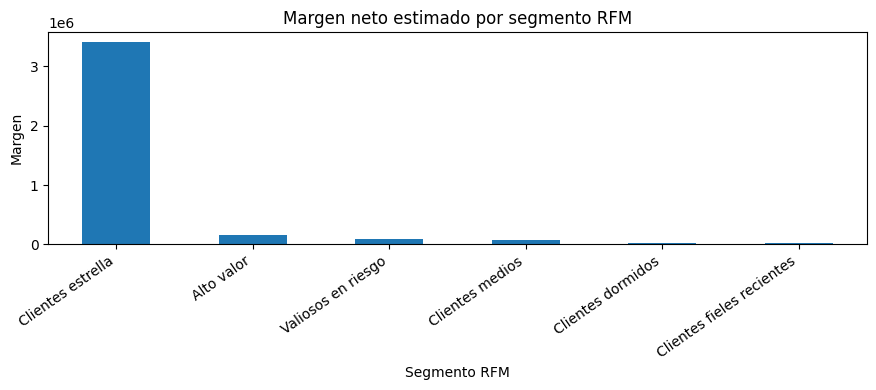

In [4]:
ax = rfm_summary['margen'].plot(kind='bar', figsize=(9, 4), title='Margen neto estimado por segmento RFM')
ax.set_xlabel('Segmento RFM')
ax.set_ylabel('Margen')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

## Riesgo de churn

El score de churn combina recencia, frecuencia, devoluciones y valor historico. Sirve para priorizar recuperacion comercial.

In [5]:
churn_summary = df.groupby('churn_risk_level').agg(
    clientes=('customer_id', 'count'),
    margen=('margen_neto_estimado', 'sum'),
    recencia_media=('recencia_dias', 'mean'),
    churn_medio=('churn_risk_score', 'mean'),
).sort_values('churn_medio', ascending=False)
churn_summary.round(2)

,clientes,margen,recencia_media,churn_medio
churn_risk_level,,,,
Critico,619,"71,833.28","1,287.35",77.30
Alto,2456,"250,087.60","1,096.14",63.19
Medio,930,"1,477,130.00",299.62,46.16
Bajo,1745,"1,962,097.24",60.02,18.21


In [6]:
df.query("churn_risk_level in ['Critico', 'Alto']").sort_values(
    ['churn_risk_score', 'margen_neto_estimado'],
    ascending=[False, False],
)[[
    'customer_id',
    'full_name',
    'recencia_dias',
    'numero_compras',
    'margen_neto_estimado',
    'churn_risk_score',
    'churn_risk_level',
    'segmento_rfm',
    'recommended_action',
]].head(15)

,customer_id,full_name,recencia_dias,numero_compras,margen_neto_estimado,churn_risk_score,churn_risk_level,segmento_rfm,recommended_action
1939,1929,Elvira Calderón Canales,976,1,160.00,95,Critico,Valiosos en riesgo,Recuperacion prioritaria de alto valor
3963,3953,Alberto Cuadrado Becerra,1772,1,160.00,95,Critico,Valiosos en riesgo,Recuperacion prioritaria de alto valor
3505,3495,Alberto Adán Becerra,1779,1,120.00,95,Critico,Valiosos en riesgo,Recuperacion prioritaria de alto valor
4476,4466,Eulalia Barrenechea Carmona,861,1,120.00,95,Critico,Alto valor,Recuperacion prioritaria de alto valor
4799,4789,Cloe Espinosa Chacón,1318,1,120.00,95,Critico,Valiosos en riesgo,Recuperacion prioritaria de alto valor
5272,5262,Gracia Figueroa Bravo,860,1,120.00,95,Critico,Alto valor,Recuperacion prioritaria de alto valor
3916,3906,Dario Durán Falcón,895,1,100.00,88,Critico,Valiosos en riesgo,Campana de reactivacion personalizada
5076,5066,Candelaria Arce Castell,1360,1,80.00,88,Critico,Valiosos en riesgo,Campana de reactivacion personalizada
4749,4739,Alexia Avilés Calvo,878,1,79.96,88,Critico,Alto valor,Campana de reactivacion personalizada
5352,5342,Gumersindo Bielsa Buitrago,1298,1,79.96,88,Critico,Valiosos en riesgo,Campana de reactivacion personalizada


## Clusters de clientes

Los clusters complementan RFM porque agrupan clientes por similitud matematica de comportamiento, no solo por reglas comerciales.

In [7]:
cluster_summary = df.groupby(['cluster_id', 'cluster_name']).agg(
    clientes=('customer_id', 'count'),
    ingresos=('ingresos_netos', 'sum'),
    margen=('margen_neto_estimado', 'sum'),
    recencia_media=('recencia_dias', 'mean'),
    tasa_devolucion_media=('tasa_devolucion_importe', 'mean'),
    churn_medio=('churn_risk_score', 'mean'),
).reset_index().sort_values('cluster_id')
cluster_summary.round(2)

,cluster_id,cluster_name,clientes,ingresos,margen,recencia_media,tasa_devolucion_media,churn_medio
0,0,Clientes recientes con potencial,1469,"277,210.36","110,890.52",88.14,0.01,20.51
1,1,Clientes de alto valor,746,"8,608,607.48","3,443,624.24",118.59,0.03,32.10
2,2,Clientes inactivos o en riesgo,3134,"506,059.92","202,437.04","1,064.89",0.00,62.72
3,3,Clientes con mas devoluciones,401,"10,490.10","4,196.32",790.69,0.90,67.59


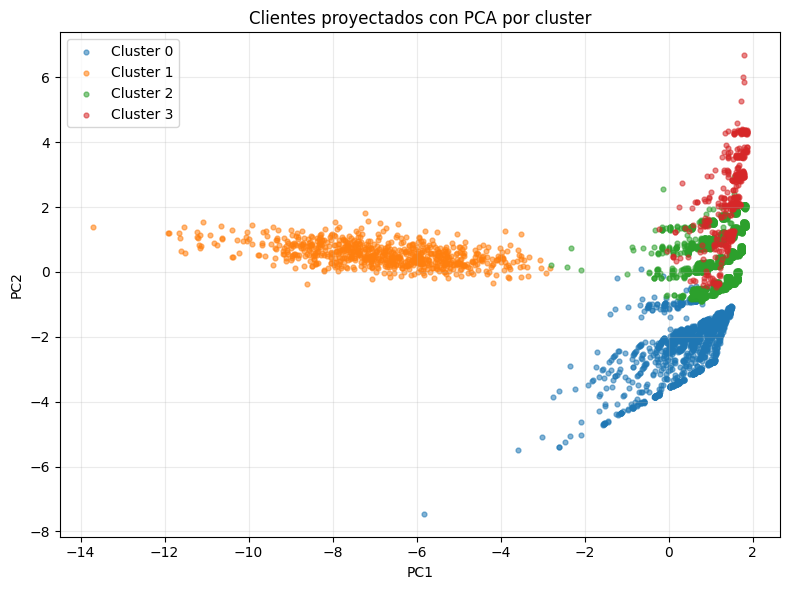

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, data in df.groupby('cluster_id'):
    ax.scatter(data['pca_1'], data['pca_2'], s=12, alpha=0.55, label=f'Cluster {cluster_id}')
ax.set_title('Clientes proyectados con PCA por cluster')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

## Cruce entre RFM y clusters

Este cruce ayuda a explicar si los grupos matematicos coinciden con los segmentos comerciales o si descubren comportamientos diferentes.

In [9]:
pd.crosstab(df['cluster_name'], df['segmento_rfm'], normalize='index').round(3)

segmento_rfm,Alto valor,Clientes dormidos,Clientes estrella,Clientes fieles recientes,Clientes medios,Valiosos en riesgo
cluster_name,,,,,,
Clientes con mas devoluciones,0.02,0.41,0.00,0.01,0.54,0.02
Clientes de alto valor,0.04,0.00,0.96,0.00,0.00,0.00
Clientes inactivos o en riesgo,0.08,0.28,0.00,0.01,0.39,0.23
Clientes recientes con potencial,0.04,0.00,0.33,0.24,0.39,0.00


## Calidad de datos: coste imputado

El producto `product_id = 29` no tenia coste en catalogo central. El DWH imputa coste analitico y conserva trazabilidad mediante `lineas_coste_imputado`.

In [10]:
df[df['lineas_coste_imputado'] > 0].agg({
    'customer_id': 'count',
    'lineas_coste_imputado': 'sum',
    'ingresos_netos': 'sum',
    'margen_neto_estimado': 'sum',
}).to_frame('valor')

,valor
customer_id,453.00
lineas_coste_imputado,711.00
ingresos_netos,"5,202,612.19"
margen_neto_estimado,"2,081,158.29"


## Conclusiones ejecutivas

- Los clientes de alto valor concentran la mayor parte del margen y deben protegerse con fidelizacion.
- Los clientes con churn alto o critico deben priorizarse por margen y accion recomendada.
- El cluster de devoluciones permite separar problemas de valor de problemas de experiencia o calidad.
- La imputacion de coste evita perder margen analitico sin ocultar la incidencia original.
- Para el detalle metodologico, usar los notebooks por fase `00` a `05`.